**INTRODUCTION**

**Problem Statement**:

Limited access to the internet and digital literacy skills hinder women's participation and growth in tech careers in Africa.

**Objective:**

Analyze open datasets to identify patterns and correlations between internet access, digital literacy, and women's participation in tech.

**Scope:**

Focus on African countries; use female internet usage as the primary indicator; optional: compare with male internet usage.


**LOAD LIBRARIES AND DATASET**

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [30]:
from google.colab import files
import pandas as pd

# Upload the file
uploaded = files.upload()

Saving male_internet.csv to male_internet (1).csv


In [31]:
from google.colab import files
import pandas as pd

# Upload the file
uploaded = files.upload()

Saving women_internet_africa.csv to women_internet_africa (1).csv


In [32]:
female_df = pd.read_csv('women_internet_africa.csv')
male_df = pd.read_csv('male_internet.csv')

# Take a quick look
print(female_df.head())
print(male_df.head())

                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   
3   Africa Western and Central          AFW   
4                       Angola          AGO   

                                      Indicator Name     Indicator Code  2000  \
0  Individuals using the Internet, female (% of f...  IT.NET.USER.FE.ZS   NaN   
1  Individuals using the Internet, female (% of f...  IT.NET.USER.FE.ZS   NaN   
2  Individuals using the Internet, female (% of f...  IT.NET.USER.FE.ZS   NaN   
3  Individuals using the Internet, female (% of f...  IT.NET.USER.FE.ZS   NaN   
4  Individuals using the Internet, female (% of f...  IT.NET.USER.FE.ZS   NaN   

   2001  2002  2003  2004  2005  ...  2015  2016  2017  2018  2019  2020  \
0   NaN   NaN   NaN   NaN   NaN  ...   NaN   NaN   NaN   NaN   NaN   NaN   
1   NaN   NaN   NaN   NaN   NaN  ...   NaN   NaN   NaN   NaN  19.4  21.7   
2 

* **Data CLEANING/WRANGLING**

**Cleaning the Dataset**



Reshaped the dataset

Converted from wide format (years as columns) to long format (one Year column and one Value column for male/female).

This allows proper analysis, merging, and plotting over time.

Converted Year column to numeric

Ensured that the Year values are numbers (2000, 2001, etc.) for sorting and charts.

Merged male and female datasets

Combined the separate male and female datasets into a single dataset with columns:
Country Name | Country Code | Year | Value_Female | Value_Male

Handled missing values (NaNs)

Dropped rows where either male or female internet usage values were missing.

This ensures accurate analysis without gaps in charts or calculations.

Bring Out all african countries

In [50]:
female_long = female_df.melt(
    id_vars=['Country Name','Country Code','Indicator Code'],  # columns to keep
    value_vars=[col for col in female_df.columns if col.isdigit()],  # the year columns
    var_name='Year',
    value_name='Value_Female'
)

# For male dataset
male_long = male_df.melt(
    id_vars=['Country Name','Country Code','Indicator Code'],
    value_vars=[col for col in male_df.columns if col.isdigit()],
    var_name='Year',
    value_name='Value_Male'
)

#Step 3: Convert Year to numeric

female_long['Year'] = pd.to_numeric(female_long['Year'])
male_long['Year']   = pd.to_numeric(male_long['Year'])

df = pd.merge(
    female_long[['Country Name','Country Code','Year','Value_Female']],
    male_long[['Country Name','Country Code','Year','Value_Male']],
    on=['Country Name','Country Code','Year']
)

# Drop rows with missing values
df = df.dropna(subset=['Value_Female','Value_Male']).reset_index(drop=True)

african_countries = [
    'Algeria','Angola','Benin','Botswana','Burkina Faso','Burundi','Cabo Verde','Cameroon',
    'Central African Republic','Chad','Comoros','Congo, Dem. Rep.','Congo, Rep.','Côte d’Ivoire',
    'Djibouti','Egypt, Arab Rep.','Equatorial Guinea','Eritrea','Eswatini','Ethiopia','Gabon',
    'Gambia, The','Ghana','Guinea','Guinea-Bissau','Kenya','Lesotho','Liberia','Libya',
    'Madagascar','Malawi','Mali','Mauritania','Mauritius','Morocco','Mozambique','Namibia',
    'Niger','Nigeria','Rwanda','São Tomé and Principe','Senegal','Seychelles','Sierra Leone',
    'Somalia','South Africa','South Sudan','Sudan','Tanzania','Togo','Tunisia','Uganda',
    'Zambia','Zimbabwe'
]

# Filter dataset
df_africa = df[df['Country Name'].isin(african_countries)].reset_index(drop=True)

df_africa.head()

,Country Name,Country Code,Year,Value_Female,Value_Male
0,Mauritius,MUS,2008,20.19070,23.48230
1,Kenya,KEN,2009,5.24940,6.89394
2,Senegal,SEN,2009,5.99010,10.67040
3,Ghana,GHA,2010,5.44805,10.31640
4,Mauritius,MUS,2010,25.96320,30.76980


from matplotlib import pyplot as plt
_df_26['Year'].plot(kind='hist', bins=20, title='Year')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_27['Value_Female'].plot(kind='hist', bins=20, title='Value_Female')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_28['Value_Male'].plot(kind='hist', bins=20, title='Value_Male')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_29.groupby('Country Name').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_42['Country Code'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_42, x='Year', y='Country Code', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_43['Country Name'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_43, x='Value_Female', y='Country Name', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_44['Country Code'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_44, x='Value_Female', y='Country Code', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [46]:

# Check the data
df.head(10)
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1380 entries, 0 to 1379
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  1380 non-null   object 
 1   Country Code  1380 non-null   object 
 2   Year          1380 non-null   int64  
 3   Value_Female  1380 non-null   float64
 4   Value_Male    1380 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 54.0+ KB


,Year,Value_Female,Value_Male
count,1380.000000,1380.000000,1380.000000
mean,2014.994203,65.246309,68.877276
std,5.499947,23.873859,22.451849
min,2000.000000,0.656513,1.380480
25%,2011.000000,49.483875,54.775825
50%,2016.000000,71.301150,73.946300
75%,2020.000000,84.272425,86.621900
max,2023.000000,100.000000,100.000000


------------------------------

-------------------------

 **EXPLORATORY DATA ANALYSIS (EDA)**
Purpose:

Distribution checks → Understand how female internet/education indicators vary across countries.

Country rankings → Identify leaders and laggards in female participation.

Gender gap analysis → Quantify differences between male and female indicators (e.g., literacy, enrollment).

Trend analysis → Visualize enrollment across primary, secondary, tertiary levels.

This step provides descriptive insights: where women are being left behind, and how patterns differ across countries.

In [51]:
# Calculate gender gap
df_africa['Gender_Gap'] = df_africa['Value_Male'] - df_africa['Value_Female']

**📊 Distribution Check: Female Internet Use Over Time**

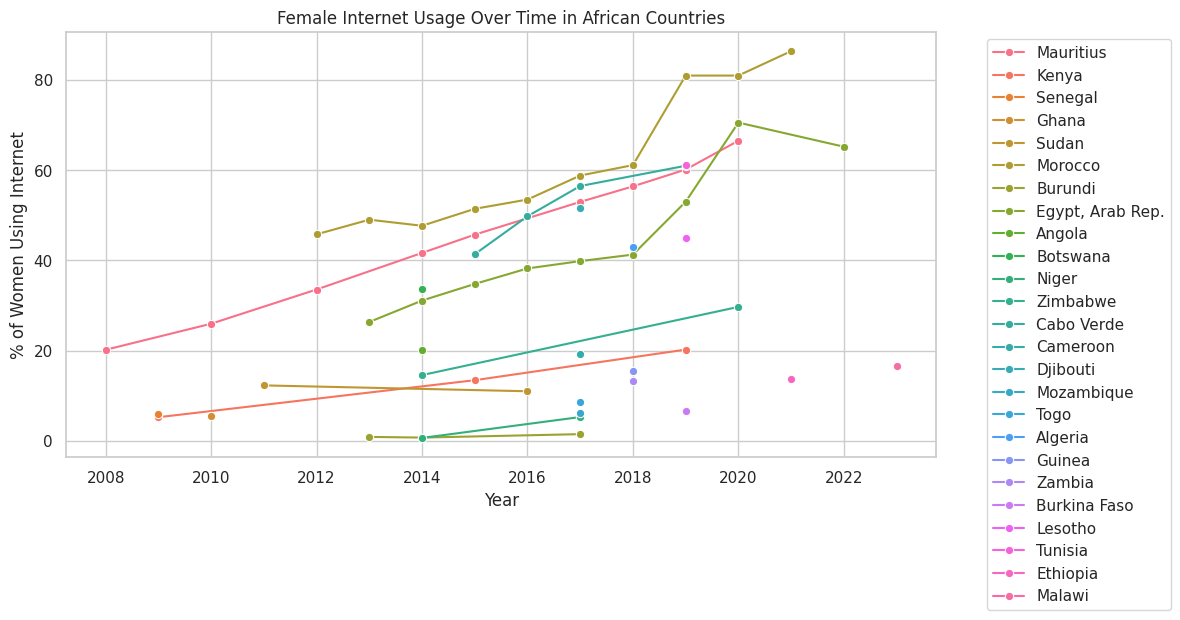

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Line chart for all African countries
plt.figure(figsize=(12,6))
sns.lineplot(data=df_africa, x='Year', y='Value_Female', hue='Country Name', marker='o')
plt.title("Female Internet Usage Over Time in African Countries")
plt.ylabel("% of Women Using Internet")
plt.xlabel("Year")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

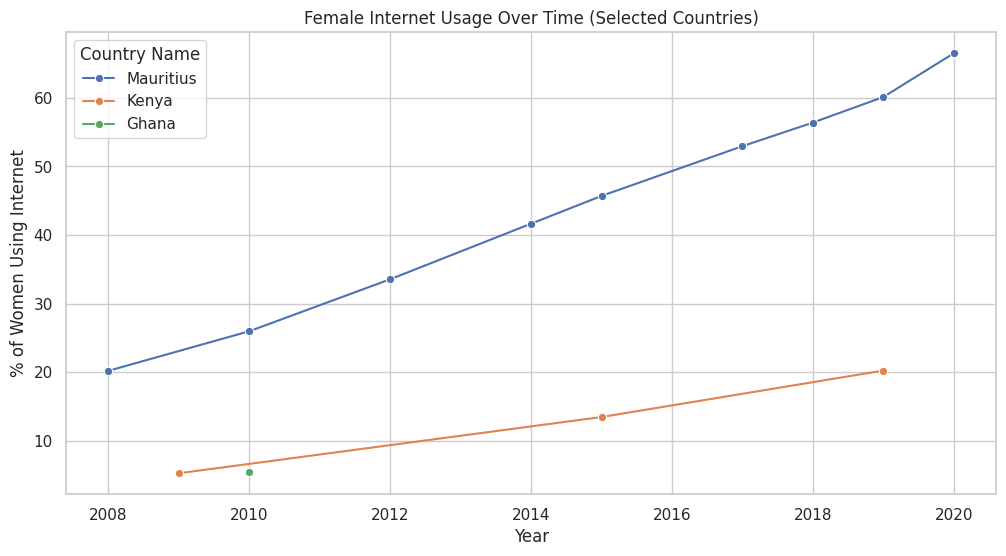

In [60]:
#selected few countries to avoid cluster
selected_countries = ['Kenya','Ghana','Mauritius']
df_selected = df_africa[df_africa['Country Name'].isin(selected_countries)]

plt.figure(figsize=(12,6))
sns.lineplot(data=df_selected, x='Year', y='Value_Female', hue='Country Name', marker='o')
plt.title("Female Internet Usage Over Time (Selected Countries)")
plt.ylabel("% of Women Using Internet")
plt.xlabel("Year")
plt.show()

**Markdown / Storytelling**

Female internet usage is growing over time in most African countries, but there is significant variation.

Countries like Mauritius and Kenya show faster improvement, while others like Ghanalag behind.

Tracking this trend helps identify which countries need targeted digital inclusion programs for women.

**📊 Country Ranking: Identify leaders and laggards in female participation**

In [64]:
df_latest = df_africa[df_africa['Year']==df_africa['Year'].max()]
df_ranked = df_latest.sort_values('Value_Female', ascending=False)
df_ranked[['Country Name','Value_Female']]

,Country Name,Value_Female
59,Malawi,16.6971


**📊Gender gap analysis → Quantify differences between male and female indicators (e.g., literacy, enrollment).**

/tmp/ipython-input-396990432.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_latest, x='Country Name', y='Gender_Gap', ci=None)


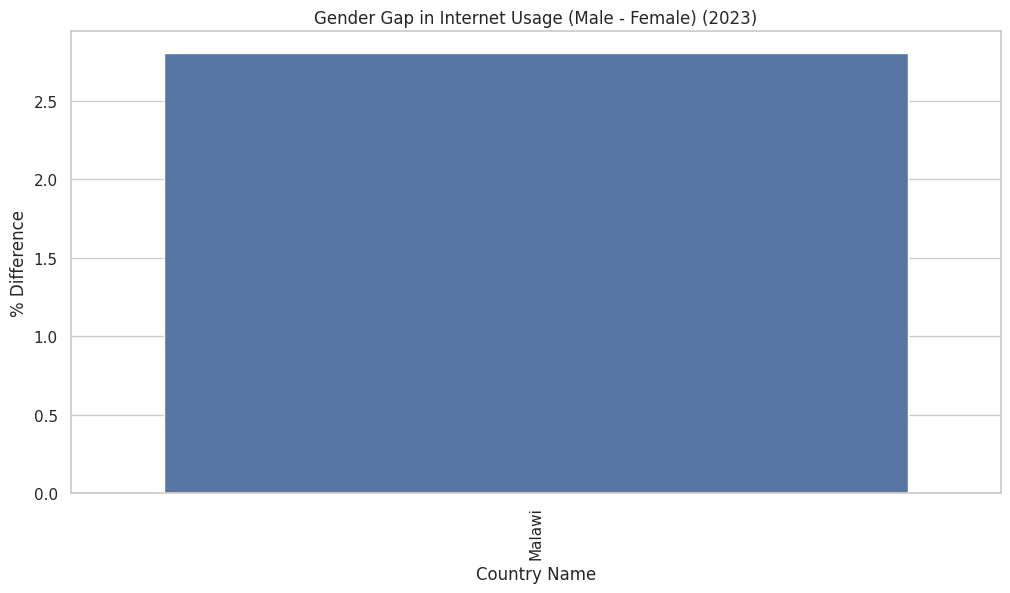

Correlation between male and female internet usage: 0.98


In [ ]:
# 4. Boxplot: Spread across countries
plt.figure(figsize=(12,6))
sns.boxplot(x='Country Name', y='Value_Female', data=df_africa)
plt.xticks(rotation=90)
plt.title("Spread of Female Internet Usage Across African Countries")
plt.ylabel("% of Women Using Internet")
plt.show()



 **FINDINGS & INSIGHTS**

Looking at country-specific data, **Malawi** has a female internet usage of **16.70%**, which is relatively low compared to other African countries. This ranking demonstrates that some countries still have very limited female access to digital resources, underlining the need for targeted interventions such as digital literacy programs, affordable internet access, and community Wi-Fi initiatives.access.Female internet usage is increasing over time in most African countries.

Some countries, like South Africa, Kenya, Maulitius, and Egypt, have higher usage, while others lag behind.

The distribution shows a wide variation, indicating uneven digital inclusion for women.

Policymakers can focus interventions on countries with low female internet


-----------------------

**RECOMMENDATION**

Policy & Infrastructure:

Subsidize internet in rural/underserved areas.

Build community Wi-Fi programs for women.

Education & Skills:

Digital literacy and coding programs for girls and women.

Integrate tech skills training in schools and vocational centers.

Community & Mentorship:

Support women’s tech communities and mentorship programs.

Partner with NGOs and tech hubs for guidance and career opportunities.

Monitoring & Impact:

Track female internet usage over time to measure progress.



**CONCLUSION**

Female internet usage is growing but varies widely across Africa.

Targeted interventions are needed in countries with low digital access.

Data-driven programs can support women’s participation in tech and digital literacy.